## Decision Tree and Random Forest with Sklearn

In [1]:
!curl https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/rpart/kyphosis.csv >> kyphosis.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1503  100  1503    0     0   1630      0 --:--:-- --:--:-- --:--:--  1630


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("kyphosis.csv")

In [8]:
df.head()

,rownames,Kyphosis,Age,Number,Start
0,1,absent,71,3,5
1,2,absent,158,3,14
2,3,present,128,4,5
3,4,absent,2,5,1
4,5,absent,1,4,15


In [9]:
df = df.drop('rownames', axis=1)

In [10]:
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


#### Exploratory Data Analysis

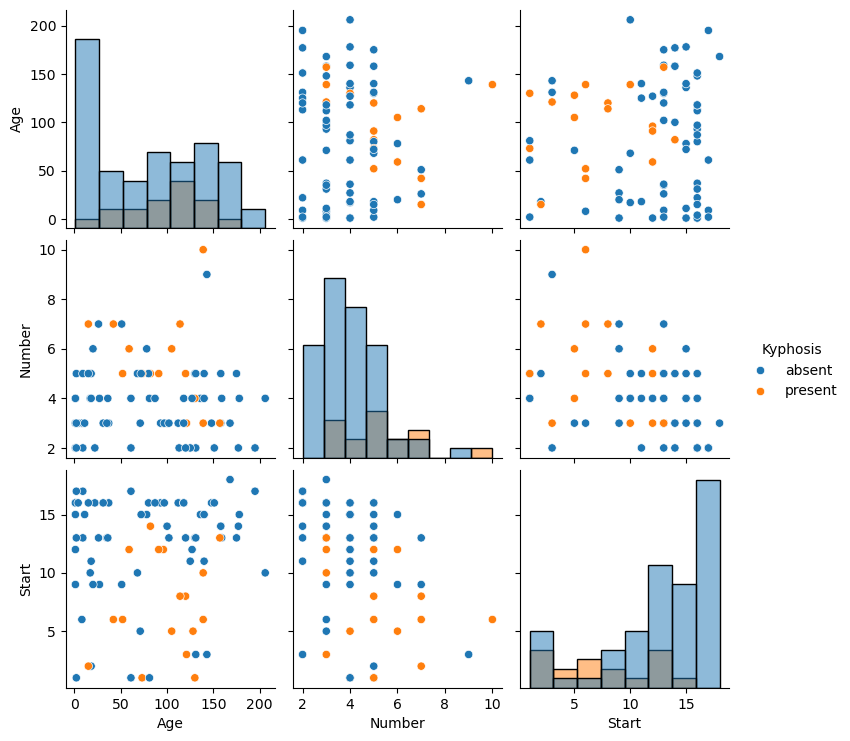

In [12]:
sns.pairplot(df, hue="Kyphosis", diag_kind='hist');

#### Train test split

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X = df.drop('Kyphosis', axis=1)
y = df['Kyphosis']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.67, shuffle=True, random_state=42)

### Decision Tree Classification

In [16]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
dtc = DecisionTreeClassifier()

In [18]:
dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Prediction and Evaluation

In [19]:
pred = dtc.predict(X_test)

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

In [21]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

      absent       0.80      0.76      0.78        21
     present       0.29      0.33      0.31         6

    accuracy                           0.67        27
   macro avg       0.54      0.55      0.54        27
weighted avg       0.69      0.67      0.68        27



In [22]:
print(confusion_matrix(y_test, pred))

[[16  5]
 [ 4  2]]


#### Tree visualization

In [25]:
from IPython.display import Image
from six import StringIO
from sklearn.tree import export_graphviz
import pydot

features = list(df.columns[1:])
features

['Age', 'Number', 'Start']

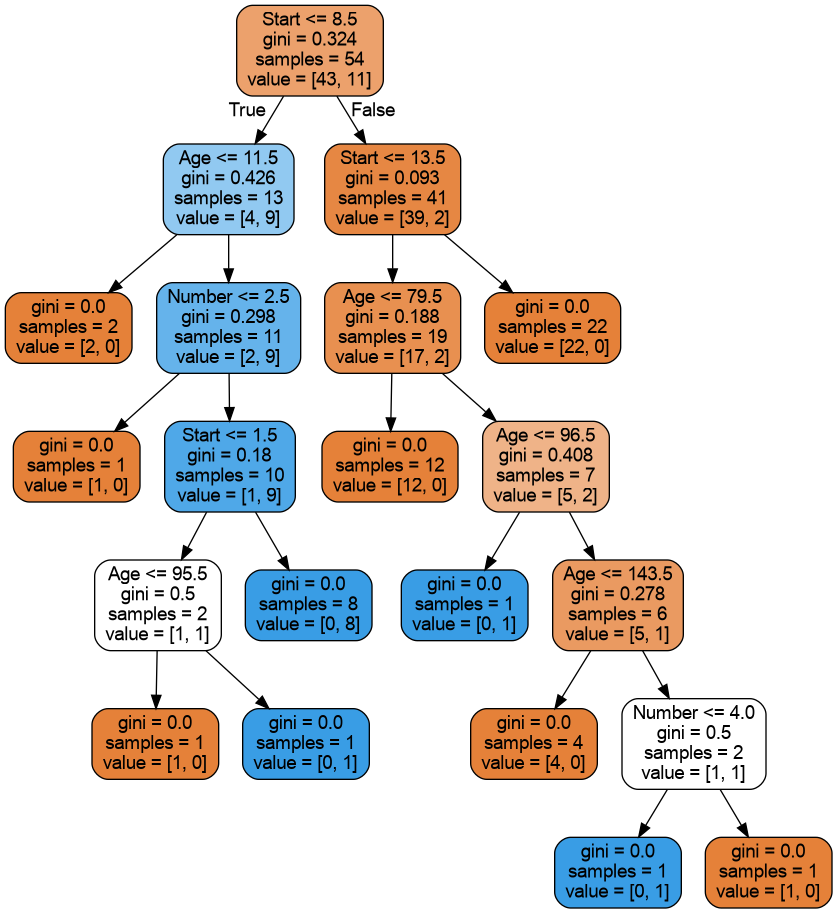

In [27]:
dot_data = StringIO()
export_graphviz(dtc, out_file=dot_data, feature_names=features, filled=True, rounded=True)
graph = pydot.graph_from_dot_data(dot_data.getvalue())
Image(graph[0].create_png())

### Random Forests Classification

In [31]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
rfc_pred = rfc.predict(X_test)
print(classification_report(y_test, rfc_pred))

              precision    recall  f1-score   support

      absent       0.83      0.95      0.89        21
     present       0.67      0.33      0.44         6

    accuracy                           0.81        27
   macro avg       0.75      0.64      0.67        27
weighted avg       0.80      0.81      0.79        27



In [33]:
print(confusion_matrix(y_test, rfc_pred))

[[20  1]
 [ 4  2]]
